## 《猫步》

午后的阳光像猫的尾巴
轻轻扫过窗台
我的诗稿在桌上摊开
像一片懒洋洋的沙滩

它不知何时占领了键盘
把每个字母踩成梅花
显示器突然弹出
一串乱码组成的
呼噜声

墨水在笔尖凝固
而它舔着爪子
把一句未完成的诗
舔成了
一团毛线球

我放下笔
看它追逐光斑
在房间里跑出
弯曲的括号
逗号 省略号
以及一个
完美的句号


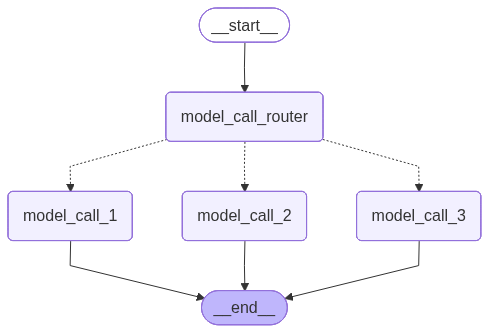

In [2]:
from pydantic import BaseModel, Field
from typing import Literal,TypedDict
from langgraph.graph import StateGraph, START, END
from langchain.messages import HumanMessage, SystemMessage

from langchain_deepseek import ChatDeepSeek

from dotenv import load_dotenv
load_dotenv(override=True)

model = ChatDeepSeek(
    model="deepseek-v4-flash",
    extra_body={
        "thinking": {
            "type": "disabled"
        }
    }
)

# 定义用于结构化输出的 Schema，作为路由判断依据
class Route(BaseModel):
    step: Literal["poem", "story", "joke"] = Field(
        None,
        description="路由流程中的下一执行步骤",
    )

# 为大模型添加结构化输出能力
router = model.with_structured_output(Route)

# 图状态
class OverAllState(TypedDict):
    input: str
    decision: str
    output: str

# 节点
def model_call_1(state: OverAllState) -> OverAllState:
    """生成故事"""

    result = model.invoke(
        [HumanMessage(content=state["input"])]
    )
    return {"output": result.content}


def model_call_2(state: OverAllState) -> OverAllState:
    """生成笑话"""

    result = model.invoke(
        [HumanMessage(content=state["input"])]
    )
    return {"output": result.content}


def model_call_3(state: OverAllState) -> OverAllState:
    """生成诗歌"""

    result = model.invoke(
        [HumanMessage(content=state["input"])]
    )
    return {"output": result.content}


def model_call_router(state: OverAllState) -> OverAllState:
    """将用户输入路由到合适的节点"""

    # 调用具有结构化输出能力的大模型，完成路由判断
    decision = router.invoke(
        [
            SystemMessage(
                content=(
                    "根据用户的请求，将其路由到 story、joke 或 poem。"
                    "请求编写故事时返回 story，请求编写笑话时返回 joke，"
                    "请求编写诗歌时返回 poem。"
                )
            ),
            HumanMessage(content=state["input"]),
        ]
    )

    return {"decision": decision.step}


# 条件边函数：根据路由决策选择下一个节点
def route_decision(
        state: OverAllState
) -> Literal[
    "model_call_1",
    "model_call_2",
    "model_call_3",
    END
]:
    # 返回接下来要执行的节点名称
    if state["decision"] == "story":
        return "model_call_1"
    elif state["decision"] == "joke":
        return "model_call_2"
    elif state["decision"] == "poem":
        return "model_call_3"
    return END


# 构建工作流
builder = StateGraph(OverAllState)

# 添加节点
builder.add_node("model_call_1", model_call_1)
builder.add_node("model_call_2", model_call_2)
builder.add_node("model_call_3", model_call_3)
builder.add_node("model_call_router", model_call_router)

# 添加边，连接各个节点
builder.add_edge(START, "model_call_router")
builder.add_conditional_edges(
    "model_call_router",
    route_decision,
    {
        # route_decision 返回的名称：接下来要执行的节点名称
        "model_call_1": "model_call_1",
        "model_call_2": "model_call_2",
        "model_call_3": "model_call_3",
    },
)
builder.add_edge("model_call_1", END)
builder.add_edge("model_call_2", END)
builder.add_edge("model_call_3", END)

# 编译工作流
graph = builder.compile()

# 调用工作流
state = graph.invoke({"input": "写一个关于猫的诗"})
print(state["output"])

# 显示工作流图
from IPython.display import display
display(graph)